In [15]:
import torch
from torch import nn
import matplotlib.pyplot as plt 

# Comprobar la version de PyTorch
torch.__version__

'2.5.1+cu121'

In [16]:
# Crear nuevos parametros
volumen = 0.8
sesgo = 0.2

# Crear datos
inicio = 0
final = 1
step = 0.025
X = torch.arange(inicio, final, step).unsqueeze(dim=1)
print(f"Shape de X: {X.shape}")
y = volumen * X + sesgo
print(f"Shape de y: {y.shape}")

X[:10], y[:10]

Shape de X: torch.Size([40, 1])
Shape de y: torch.Size([40, 1])


(tensor([[0.0000],
         [0.0250],
         [0.0500],
         [0.0750],
         [0.1000],
         [0.1250],
         [0.1500],
         [0.1750],
         [0.2000],
         [0.2250]]),
 tensor([[0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800]]))

Necesitamos un conjunto de prueba y uno de entrenamiento

Cada conjunto tiene un objetivo especifico:
 - Conjunto de entrenamiento: El modelo aprende de los datos
 - Conjunto de prueba: El modelo se evalua con los datos para probar lo que ha aprendido

In [17]:
# Crea la division

train_division = int(0.7 * len(X)) # 70% de los datos utilizados para el conjunto de entrenamiento, 30% para pruebas
X_train, y_train = X[:train_division], y[:train_division]
X_prueba, y_prueba = X[train_division:], y[train_division:]


In [18]:
len(X_train), len(X_prueba)

(28, 12)

Tenemos 28 muestras para entrenamiento (X_train, y_train) y 12 muestras de prueba (X_prueba, y_prueba)

Visualizamos nuestros datos

In [19]:
def plot_predictions(datos_ent=X_train, etiq_ent = y_train, datos_prueba=X_prueba, etiq_prueba = y_prueba, predictions = None):
    """
    Traza datos de entrenamiento, datos de prueba y compara predicciones
    """
    plt.figure(figsize=(10, 10))

    # Traza datos de entrenamiento en verde
    plt.scatter(datos_ent, etiq_ent, c="g", s=6, label="Datos de entrenamiento")

    # Traza datos de prueba en amarillo
    plt.scatter(datos_prueba, etiq_prueba, c="y", s=6, label="Datos prueba")

    if predictions is not None:
        # Traza las predicciones en rojo
        plt.scatter(datos_prueba, predictions, c="r", s=6, label="Predicciones")

    # Leyenda
    plt.legend(prop={"size": 10})

    # Mostrar el plot
    plt.show()

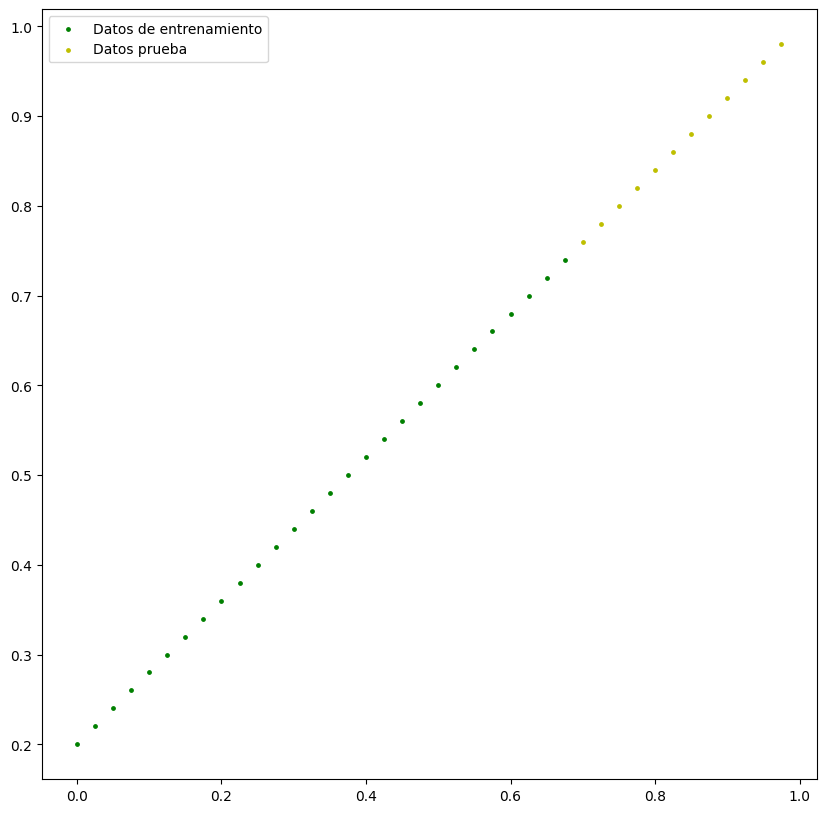

In [21]:
plot_predictions()